In [727]:
# Initialize Otter
import otter
grader = otter.Notebook("Project3.ipynb")

# Project 3 - Random Forest Classifer and Expected Goals (xG)

In this project you'll be using a Random Forest Classifier to train a model that predicts the probability of a goal ($y=1$) being scored in a soccer match based on where and how the shot was taken $X_{shot}$.
$$P(y=Goal | X_{shot})$$

In a game with $N$ shots expected goals (xG) is the sum over these probabilities.  

$$xG= \sum_{i=1}^{N} P_i(y=Goal | X_{shot,i})$$

* This metric is call 'expected' goals, because this is what you would expect the mean number of goals to be if this same game was played over and over again.
* The game has a total xG and each shot has it's own xG ( $P_i(y=Goal | X_{shot,i})$), both are used
* It's a useful indicator of how good a team is doing tactically, which is harder to do with the actual scores in soccer because soccer scores tend to be low, and hence more susceptible to random chance.
* We'll also use a new useful concept call 'calibration', which checks if our estimated probability is correct. I.e, if the classifier says $P(y=Goal | X_{shot})=0.2$ then 1 in 5  shots with this $X_{shot}$ should be goals, no more and no less. 

# Data

This data comes from  Stats Bomb https://github.com/statsbomb/open-data

<img src='https://upload.wikimedia.org/wikipedia/en/3/31/Hudlvideologo.png' width=200px>

* Train data - Several seasons of top league (US, Germany, England) and World Cup  Women's Soccer games
* Test Game - Portland Thorns vs. Utah Royals July 6th - [highlights](https://youtu.be/IRbTkHNXe4s?si=lBAinf5Zm_o98E6R)
* Test Season - Women's 2023 World-Cup

In [728]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from  sklearn.ensemble import  RandomForestClassifier
from sklearn.calibration import CalibrationDisplay
from scipy.stats import poisson_binom
import scipy,sklearn

In [729]:
# Helpful for grading
print("pandas:",pd.__version__)
print("scipy:",scipy.__version__)
print("sklearn:",sklearn.__version__)
print("numpy:",np.__version__)


pandas: 2.2.3
scipy: 1.15.3
sklearn: 1.6.1
numpy: 2.4.1


# Process Data
I've provided you as starting point for processing the data

In [730]:
input_df=pd.read_csv('xg_train.csv')
input_y=input_df['is_goal']
input_df=input_df.drop(columns=['is_goal'])
string_cols = input_df.select_dtypes(include=["object", "string"]).columns
numeric_cols = input_df.select_dtypes(include=["number"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), string_cols),
        ("num", StandardScaler(), numeric_cols)],    
        verbose_feature_names_out=False,
        remainder="drop",
        sparse_threshold=0,
)

X_processed = preprocess.fit_transform(input_df)
df_processed = pd.DataFrame(X_processed, columns=list(preprocess.get_feature_names_out()))


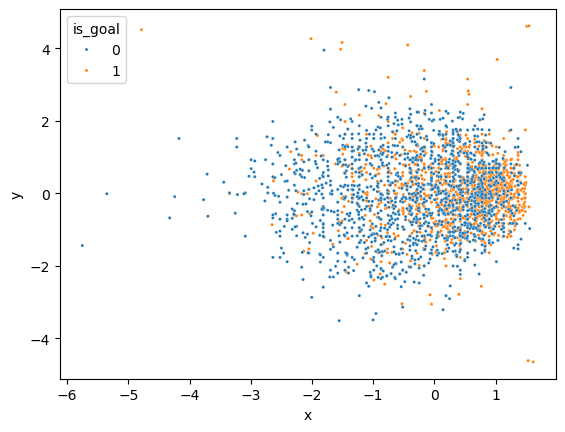

In [731]:
import seaborn as sns
sns.scatterplot(df_processed,x='x',y='y',hue=input_y,s=5)
plt.show()

# Task 1 Split Data (10-points)
We've done this a bunch of times, but I want you to go through all the steps here
* Split X_processed into X_train, X_test, y_train, y_test with a 20% split

In [732]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, input_y, test_size = .20)

In [733]:
grader.check("Task 1")

Task 1 results: All test cases passed!

# Calibration Concepts
Read the following to better understand the next task

## Expected Calibration Error (ECE)

**Expected Calibration Error (ECE)** measures how well a model’s predicted probabilities align with true empirical frequencies. 
### Definition

For each sample, take the predicted class and its associated probability (the **confidence**). Partition the interval \([0,1]\) into \(K\) bins. For each bin \(B_k\), compute:

- **rate(k)** = $1/N\sum_{i\in k} y_i$  
- **conf(k)** = $1/N\sum_{i\in k} \hat{y}_i$   
- **$|B_k| / N$** — the bin’s proportion of total samples

The ECE is the weighted sum of calibration gaps between bins:

$$
\text{ECE} = \sum_{k=1}^{K} \frac{|B_k|}{N} \left| \text{rate}(k) - \text{conf}(k) \right|.
$$

- Lower ECE → better calibration  
- ECE = 0 indicates perfect calibration

# Calibration Plots
We an also make 'Calibration Plots' that show this graphically, in these plots you want the model's output to be as close to the dotted straight line as possible. Anywhere the points are above the line means that the model is under-confident and there are more positives than expected. Anywhere the points are below the line means that the model is over-confident and there are less positives than expected.

<img src=https://scikit-learn.org/stable/_images/sphx_glr_plot_compare_calibration_001.png>


In [734]:
# Caculate ece
def ece(y_true, y_prob):
    n_bins=10
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    assert y_prob.ndim == 1
    conf = y_prob    
    bins = np.linspace(0, 1, n_bins+1)
    b = np.digitize(conf, bins) - 1
    e = 0.
    for i in range(n_bins):
        m = b == i
        if m.any():
            e += m.mean() * abs(y_true[m].mean() - conf[m].mean())
    return e

# Task 2 Train a Model (20-points)

* Goal is to find the hyper-parameters that
    * Don't over fit
         * Train and test accuracy differ by less than 1.5%
    * Are well calibrated
        * Calibration plots for train and test are close to straight lines
        * ECE score for train and test less than 0.07
    * Accuracy at least 67% on both train and test


In [735]:
hyper_parameters={
                  'max_depth':None,
                  'min_samples_leaf':50,
                 #....
                  'n_estimators': 100,
                  'criterion': 'gini',
                  'min_weight_fraction_leaf': 0.0,
                  'min_samples_split': 100,
                  # 'bootstrap': True,
                  # 'max_features': None,
                  # 'random_state': 50,
                  # 'verbose': 0.0,
    
                 }
...

# train and test acc differ by less than 1.5%

# plots for train and test are close to straight lines

# ECE score for train and test less than 0.07

# accuracy at least 67% on both train and test

Ellipsis

Train Accuracy 0.7062196735774151 Train Accuracy 0.6984126984126984
Train ECE 0.03271257503214987 Test 0.04269806253981299


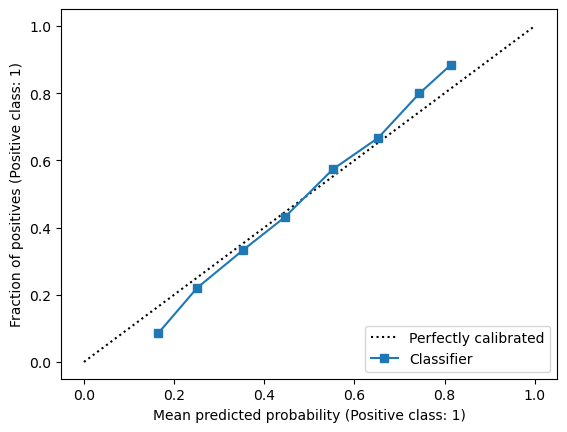

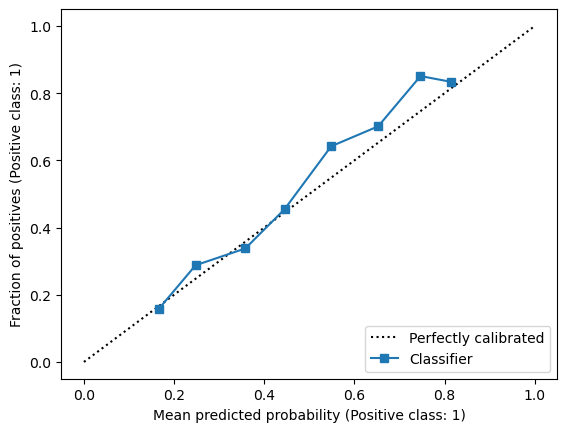

In [736]:
# Keep this code the same
model=RandomForestClassifier(**hyper_parameters)
res=model.fit(X_train,y_train)
train_probs=model.predict_proba(X_train)
test_probs=model.predict_proba(X_test)

train_acc=(y_train==(train_probs[:,1]>0.5)).mean()
test_acc=(y_test==(test_probs[:,1]>0.5)).mean()

train_ece=ece(y_train,train_probs[:,1])
test_ece=ece(y_test,test_probs[:,1])

CalibrationDisplay.from_predictions(y_train, train_probs[:,1],n_bins=10)
CalibrationDisplay.from_predictions(y_test, test_probs[:,1],n_bins=10)

print(f"Train Accuracy {train_acc} Train Accuracy {test_acc}")
print(f"Train ECE {train_ece} Test {test_ece}")

In [737]:
grader.check("Task 2")

Task 2 results: All test cases passed!

# Task 3 Apply This to a Test Game (10-points)
1. Use the same model trained above to predict the probabilities for each shot in the game
2. Assign this to a column name 'xG' in the test_game dataframe i.e. (test_game['xG']=probs)

In [738]:
test_game=pd.read_csv('test_game.csv')
display(test_game)

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id
0,9154,7477,Portland Thorns,Tobin Powell Heath,1,0,103.0,36.0,17.464249,0.231091,Right Foot,Normal,Regular Play,1,49,3
1,9155,7477,Portland Thorns,Tobin Powell Heath,4,4,105.0,51.0,18.601075,0.632749,Left Foot,Half Volley,From Throw In,0,49,3
2,9156,7477,Utah Royals,Diana Matheson,9,24,103.0,33.0,18.384776,0.390607,Right Foot,Normal,From Throw In,0,49,3
3,9157,7477,Portland Thorns,Tobin Powell Heath,23,56,90.0,29.0,31.953091,0.351445,Right Foot,Normal,From Throw In,0,49,3
4,9158,7477,Portland Thorns,Hayley Emma Raso,27,42,94.0,36.0,26.305893,0.152649,Right Foot,Normal,Regular Play,0,49,3
5,9159,7477,Portland Thorns,Lindsey Michelle Horan,31,27,112.0,41.0,8.062258,0.124355,Head,Normal,From Free Kick,1,49,3
6,9160,7477,Portland Thorns,Ana-Maria Crnogorčević,33,21,107.0,47.0,14.764823,0.493941,Left Foot,Normal,From Counter,1,49,3
7,9161,7477,Portland Thorns,Hayley Emma Raso,45,10,107.0,45.0,13.928388,0.367174,Head,Normal,Regular Play,0,49,3
8,9162,7477,Utah Royals,Katrina Gorry,52,48,94.0,31.0,27.513633,0.333244,Left Foot,Normal,Regular Play,0,49,3
9,9163,7477,Portland Thorns,Ellie Madison Carpenter,55,25,89.0,66.0,40.459857,0.697903,Right Foot,Normal,Regular Play,0,49,3


In [750]:
# X_processed = preprocess.fit_transform(input_df)
# df_processed = pd.DataFrame(X_processed, columns=list(preprocess.get_feature_names_out()))

# train_probs=model.predict_proba(X_train)
# test_probs=model.predict_proba(X_test)


test_game_xg = preprocess.transform(test_game)
test_game_ = pd.DataFrame(test_game_xg, columns = list(preprocess.get_feature_names_out()))

# test_game_probs = model.predict_proba(test_game_)
# array([[0.52392158, 0.47607842],
#        [0.59878715, 0.40121285],
#        [0.62043498, 0.37956502],
#        [0.82087323, 0.17912677],
#        [0.71758611, 0.28241389],
#        [0.49334953, 0.50665047],
#        [0.48834547, 0.51165453],
#        [0.57439073, 0.42560927],
#        [0.73101112, 0.26898888],
#        [0.78292606, 0.21707394],
#        [0.52200473, 0.47799527],
#        [0.83512796, 0.16487204],
#        [0.28074239, 0.71925761],
#        [0.73293221, 0.26706779],
#        [0.70646126, 0.29353874],
#        [0.62910267, 0.37089733],
#        [0.82017507, 0.17982493]])
#        P(not a goal)  P(a goal)

test_game_probs = model.predict_proba(test_game_)[:, 1]
# test_game['xG'] = test_game_probs.astype(float)

# test_game.head()

# Task 3 - 3 result:
#     ❌ Test case failed
#     Trying:
#         np.sum(test_game['xG']) > 4 and np.sum(test_game['xG']) < 8
#     Expecting:
#         True
#     **********************************************************************
#     Line 1, in Task 3 2
#     Failed example:
#         np.sum(test_game['xG']) > 4 and np.sum(test_game['xG']) < 8
#     Expected:
#         True
#     Got:
#         np.True_

test_game['xG'] = pd.Series(test_game_probs.astype(object)) #fixes np.true issue
test_game.head()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id,xG
0,9154,7477,Portland Thorns,Tobin Powell Heath,1,0,103.0,36.0,17.464249,0.231091,Right Foot,Normal,Regular Play,1,49,3,0.425771
1,9155,7477,Portland Thorns,Tobin Powell Heath,4,4,105.0,51.0,18.601075,0.632749,Left Foot,Half Volley,From Throw In,0,49,3,0.411265
2,9156,7477,Utah Royals,Diana Matheson,9,24,103.0,33.0,18.384776,0.390607,Right Foot,Normal,From Throw In,0,49,3,0.378965
3,9157,7477,Portland Thorns,Tobin Powell Heath,23,56,90.0,29.0,31.953091,0.351445,Right Foot,Normal,From Throw In,0,49,3,0.155601
4,9158,7477,Portland Thorns,Hayley Emma Raso,27,42,94.0,36.0,26.305893,0.152649,Right Foot,Normal,Regular Play,0,49,3,0.237927


In [751]:
grader.check("Task 3")

Task 3 results: All test cases passed!

# Compare to the Real Game Results
Run the cell below to compare to the real game results

In [752]:
xg_res=test_game.groupby('team')[['xG','is_goal']].sum()
thorns_xg,thorns_goals=xg_res.loc['Portland Thorns'][['xG','is_goal']]
royals_xg,royals_goals=xg_res.loc['Utah Royals'][['xG','is_goal']]

print(f'Thorns xG ={round(thorns_xg,2)} goals {thorns_goals}')
print(f'Royals xG ={round(royals_xg,2)} goals {royals_goals}')


Thorns xG =3.47 goals 4
Royals xG =2.44 goals 0


# Did that work?

We want to know if our expected goals prediction is consistent with the observed goals (4-0 Thorns). How do we do this? 

## Poisson–Binomial Distribution

The **Poisson–binomial distribution** is the distribution of the sum of independent Bernoulli trials (coin flips) with (potentially) different success probabilities. Perfect for this exercise where each 'trial' is a shot with probability given by the model output (or xG)

We would say the game score $X$ is drawn from
$$X \sim \mathrm{PB}(p_1, p_2, \dots, p_n)$$

and we can caulate this using scipy's  `poisson_binom` and some of its useful functions.

 * **pmf** (Probability mass function) - in this case **pmf(N,probs)** is the likelihood of observing exactly N goas.
     * This great for individual games where there aren't too many possible outcomes 
 * **cdf** (Cumulative distribution function) -in this case **cdf(N,probs)** is the the likelihood of observing exactly N goals or less
     * This is helpful for looking a seasons where the odds of see 179, 180, and 181 goals are all similar and all small, and you want to check if your expected goals are too high (i.e. you observe less and want to know how rare seeing this observation or less is)
 * **sf**  (Survival Function (1-CDF)) distribution functions **cdf(N,probs)** is the the likelihood of observing exactly N goals or more
     * This is helpful for looking at the other side of the distribution observing to many.

### Run the cell below to get an estimate of how likely this game was

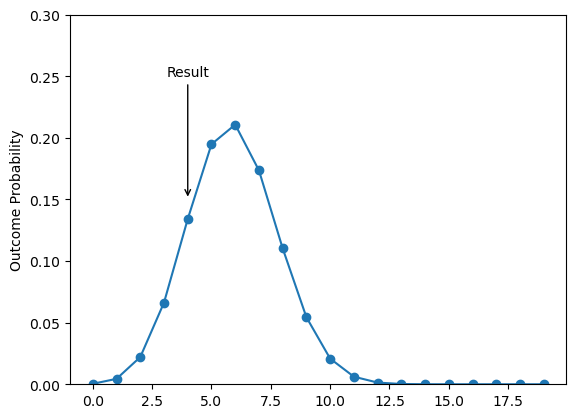

This number of goals would happen in 13.42% of games


In [753]:
all_goals=thorns_goals+royals_goals
x=range(0,20)
outcome_probs=[poisson_binom.pmf(i,test_game['xG'].values)  for i in x]
plt.plot(x,outcome_probs,'o-')
plt.ylabel('Outcome Probability')
plt.annotate('Result',(4,.15),xytext=(4,.25),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,.3)
plt.show()
outcome_percent= round(outcome_probs[int(all_goals)]*100,2)
print(f'This number of goals would happen in {outcome_percent}% of games')

<!-- BEGIN QUESTION -->

# Task 3 question: Does This Result make sense? (10-pts)
Write a few sentences describing what you see above and what that means for the quality of your model

_Type your answer here, replacing this text._

From the information that we have running our cells above, we see that:

Thorns xG =3.47 goals 4,

Royals xG =2.44 goals 0,

with out graph showing that the number of goals (4) would happen in 13.42% of games. This means that in roughly 7-8 games, we would see that many goals being scored in one game. The model overperformed by a little bit (expected 3.47, got 4), but is reasonable. For our other opponent (Royals), we expected 2.44 goals but actually got 0. From our model, we do see this as a possibility since every goal is measured independently and this is a realistic outcome. 

<!-- END QUESTION -->

# Task 4 Apply this to a Whole World Cup (10-points)
1. Use the same model trained above to predict the probabilites for each shot in the game
2. Assign this to a column named xG  i.e. test_season['xG']=probs

In [755]:
test_season=pd.read_csv("test_season.csv")

In [756]:
test_season.head()

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id
0,11155,3904629,England Women's,Georgia Stanway,8,28,111.1,30.9,12.728708,0.796509,Right Foot,Half Volley,From Free Kick,0,72,107
1,11156,3904629,England Women's,Georgia Stanway,9,5,113.3,34.1,8.927486,0.721991,Head,Normal,From Corner,0,72,107
2,11157,3904629,England Women's,Alessia Russo,9,7,112.3,37.3,8.159657,0.337253,Head,Normal,From Corner,0,72,107
3,11158,3904629,England Women's,Lauren Hemp,9,13,107.9,29.8,15.825612,0.700402,Left Foot,Volley,From Corner,0,72,107
4,11159,3904629,England Women's,Rachel Daly,12,39,112.0,38.1,8.222530,0.233180,Head,Normal,From Corner,0,72,107


In [757]:
# test_game_xg = preprocess.transform(test_game)
# test_game_ = pd.DataFrame(test_game_xg, columns = list(preprocess.get_feature_names_out()))
# test_game_probs = model.predict_proba(test_game_)[:, 1]
# test_game['xG'] = pd.Series(test_game_probs.astype(object)) #fixes np.true issue
# test_game.head()


test_season_xg = preprocess.transform(test_season)
test_season_ = pd.DataFrame(test_season_xg, columns = list(preprocess.get_feature_names_out()))

test_season_probs = model.predict_proba(test_season_)[:, 1]

test_season['xG'] = pd.Series(test_season_probs.astype(object))
test_season.head()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id,xG
0,11155,3904629,England Women's,Georgia Stanway,8,28,111.1,30.9,12.728708,0.796509,Right Foot,Half Volley,From Free Kick,0,72,107,0.568368
1,11156,3904629,England Women's,Georgia Stanway,9,5,113.3,34.1,8.927486,0.721991,Head,Normal,From Corner,0,72,107,0.492747
2,11157,3904629,England Women's,Alessia Russo,9,7,112.3,37.3,8.159657,0.337253,Head,Normal,From Corner,0,72,107,0.476874
3,11158,3904629,England Women's,Lauren Hemp,9,13,107.9,29.8,15.825612,0.700402,Left Foot,Volley,From Corner,0,72,107,0.421379
4,11159,3904629,England Women's,Rachel Daly,12,39,112.0,38.1,8.222530,0.233180,Head,Normal,From Corner,0,72,107,0.465254


In [758]:
grader.check("Task 4")

Task 4 results: All test cases passed!

# Evaluate
Run the cell below to evaluate your model

One out of roughly 137728467091875600437522125428806001690651306722543106545048410422710047631224745959646435425163017237905076453229125178888416315256711616285128399981861800334946517859101568302203028290823177774110218848238881996800.0 seasons would have 184 goals or fewer.


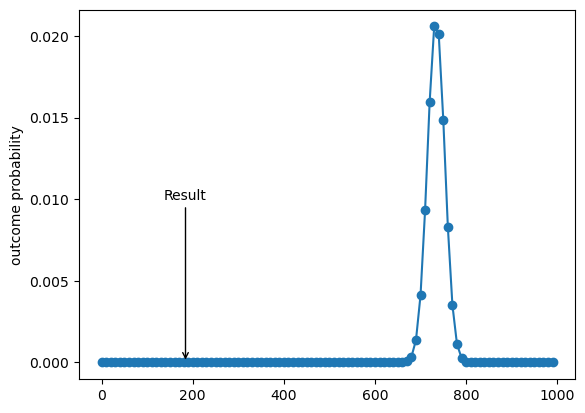

In [759]:
season_goals=test_season['is_goal'].sum()
prob_lt = poisson_binom.cdf(season_goals,test_season['xG'].values,)
print(f"One out of roughly {1/prob_lt:.1f} seasons would have {season_goals} goals or fewer.")

x=list(range(0,1000,10))
plt.plot(x,[poisson_binom.pmf(i,test_season['xG'].values)  for i in x],'o-')
plt.ylabel('outcome probability')
plt.annotate('Result',(season_goals,.0),xytext=(season_goals,.01),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.show()

<!-- BEGIN QUESTION -->

# Task 4 Question: Does This Result Make Sense? (10-points)
Write a few sentences describing what you see above,and what it means for the quality of you model.

_Type your answer here, replacing this text._

This doesn't really make sense, since out of all those seasons, only one out of ### would have 184 goals or fewer. This means that our model is predicting this number to be practically almost impossible, and is not well ccalibrated. Then we also see a massive spike in probability of goals between 700-800, and everything else is extremely flat. Our model does not generalize well and is overpredicting goals. In conclusion, this current model does not work or isn't calibrated for all teams. 

<!-- END QUESTION -->

# How Does Class Balance Change Your Classifier?
It's common that you'll get a data set that is 'balanced', in this case an equal number of shots that were goals and shots that were not. However, this isn't the case in real data, many more shots miss than go in. In fact the real class balance is:

$$\frac{ sum(is\_goal=1)}{N} = 11.3\%  \quad \frac{sum(is\_goal=0)}{N}= 88.7\%$$

## How do we get a Classifier That Respects the Real Ratio of Events

We can re-train the model with 'class weights', these 'weight' each class by value you specify. For example if you use **class_weight={0:10, 1:1}** in your Random Forest it treats class 0 as **10x** as important as class 1. 

If you want to take a balanced dataset and re-weight it to real ratio of events you can do so with the following class weights

$$\text{Weight}_i = \pi_{real,i}/\pi_{dataset,i}$$

where $\pi_{dataset,i}$ is the percentage of class  $i$ in the dataset and $\pi_{real,i}$ is the percentage for class $i$ in the real world listed above.



## Task 5 - Retrain (10 - points)

* Calculate the class weights as described above and retrain you random forest classifier with the same hyperparameter's you used before. The resulting comparison should change from the one above.
* Assign the resulting probabilities for the test game to test_game['xG_weighted']
* Assign the resulting probabilities for the test season to test_season['xG_weighted']


In [ ]:
# model=RandomForestClassifier(**hyper_parameters)
# res=model.fit(X_train,y_train)
# train_probs=model.predict_proba(X_train)
# test_probs=model.predict_proba(X_test)

# train_acc=(y_train==(train_probs[:,1]>0.5)).mean()
# test_acc=(y_test==(test_probs[:,1]>0.5)).mean()

# train_ece=ece(y_train,train_probs[:,1])
# test_ece=ece(y_test,test_probs[:,1])

# CalibrationDisplay.from_predictions(y_train, train_probs[:,1],n_bins=10)
# CalibrationDisplay.from_predictions(y_test, test_probs[:,1],n_bins=10)

# print(f"Train Accuracy {train_acc} Train Accuracy {test_acc}")
# print(f"Train ECE {train_ece} Test {test_ece}")

In [765]:
class_weights={0:1,1:1}

goal = 0.113 / 0.5 
no_goal = 0.887 / 0.5

weights = {0: no_goal, 1: goal}

hyper_parameters={
                  'max_depth':None,
                  'min_samples_leaf':50,
                 #....
                  'n_estimators': 100,
                  'criterion': 'gini',
                  'min_weight_fraction_leaf': 0.0,
                  'min_samples_split': 100,
                  'class_weight': weights,
                  # 'bootstrap': True,
                  # 'max_features': None,
                  # 'random_state': 50,
                  # 'verbose': 0.0,
    
                 }


new_model = RandomForestClassifier(**hyper_parameters)
new_model.fit(X_train, y_train)

test_game_xg_model = preprocess.transform(test_game)
test_game_xg_ = pd.DataFrame(test_game_xg_model, columns = list(preprocess.get_feature_names_out()))
test_game_probs_model = new_model.predict_proba(test_game_xg_)[:,1]
test_game['xG_weighted'] = pd.Series(test_game_probs_model.astype(object))

test_season_xg_model = preprocess.transform(test_season)
test_season_xg_ = pd.DataFrame(test_season_xg_model, columns = list(preprocess.get_feature_names_out()))
test_season_probs_model = new_model.predict_proba(test_season_xg_)[:,1]
test_season['xG_weighted'] = pd.Series(test_season_probs_model.astype(object))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [766]:
grader.check("Task 5")

Task 5 results: All test cases passed!

## Evaluate Again
Run the cell below to evaluate your weighted model


One out of roughly 20.2 seasons would have 184 goals or fewer.


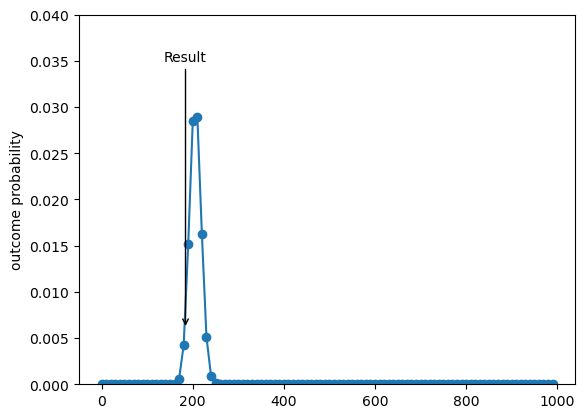

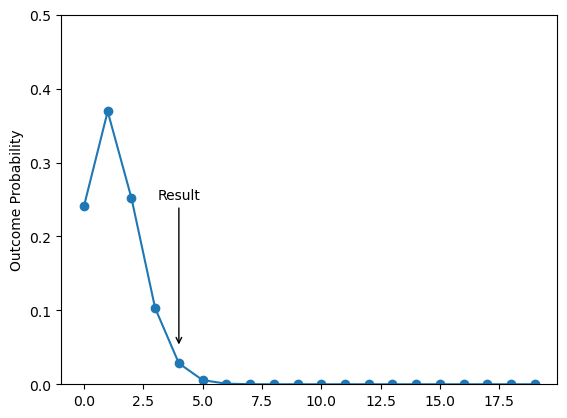

This number of goals would happen in 2.84% of games


In [767]:
prob_lt = poisson_binom.cdf(season_goals,test_season['xG_weighted'].values,)
print(f"One out of roughly {1/prob_lt:.1f} seasons would have {season_goals} goals or fewer.")

x=list(range(0,1000,10))
plt.plot(x,[poisson_binom.pmf(i,test_season['xG_weighted'].values)  for i in x],'o-')
plt.ylabel('outcome probability')
plt.annotate('Result',(season_goals,.006),xytext=(season_goals,.035),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,0.04)
plt.show()

all_goals=thorns_goals+royals_goals
x=range(0,20)
outcome_probs=[poisson_binom.pmf(i,test_game['xG_weighted'].values)  for i in x]
plt.plot(x,outcome_probs,'o-')
plt.ylabel('Outcome Probability')
plt.annotate('Result',(4,.05),xytext=(4,.25),horizontalalignment='center',arrowprops=dict(arrowstyle='->',))
plt.ylim(0,.5)
plt.show()
outcome_percent= round(outcome_probs[int(all_goals)]*100,2)
print(f'This number of goals would happen in {outcome_percent}% of games')



<!-- BEGIN QUESTION -->

# Task 5 question: Does This Result Make Sense? (10-points)
If everything above has worked, your model should be looking better. Write a few sentences describing how you can tell that from the plots and results above.

_Type your answer here, replacing this text._

These plots look a lot better since we aren't over predicting on the outcome probability of scoring 184 goals or fewer. We can see on the first graph that the numbers look more realistic and probable, showing that the highest probabilities of prediction scoring for a season tend to actually fall between ~180 to ~220. Not only that, but it's also at a better ratio (1 out of 20.2 seasons). For our second graph, we see that ~4 goals would happen in 2.84% of games, which is also a realistic measurement since scoring in soccer isn't very likely in general. We can also see on the graph how low the probability gets when passing 5 goals a game, which is realistic.

<!-- END QUESTION -->

# TASK 6 - Correct by hand
Note sometimes re-training is expensive, and we just want to correct the outcomes. It turns out you can do this with

$$p_{new} = \frac{ \frac{\pi_{real,1}}{\pi_{dataset,1}}  p_{old}}{  \frac{\pi_{real,1}}{\pi_{dataset,1}}  p_{old} +   \frac{1-\pi_{real,1}}{1-\pi_{dataset,1}}  (1-p_{old})   )}$$

* Use the above equation to calculate new weights
* assign the result to "xG_hand_weighted" in test_season and test_game

In [776]:
real_1 = 0.113
dataset = 0.5

real_data = real_1 / dataset

one_minus = (1-real_1) / (1-dataset)

p_old = test_season['xG'].values

p_new = (real_data * p_old) / (real_data * p_old + one_minus*(1 - p_old) )

test_season['xG_hand_weighted'] = p_new



g_old = test_game['xG'].values

p_new_game = (real_data * g_old) / (real_data * g_old + one_minus*(1 - g_old) )

test_game['xG_hand_weighted'] = p_new_game

# test_season.head()
test_game.head()

,Unnamed: 0,match_id,team,player,minute,second,x,y,shot_distance,shot_angle,body_part,technique,play_pattern,is_goal,competition_id,season_id,xG,xG_weighted,xG_hand_weighted
0,9154,7477,Portland Thorns,Tobin Powell Heath,1,0,103.0,36.0,17.464249,0.231091,Right Foot,Normal,Regular Play,1,49,3,0.425771,0.089605,0.086307
1,9155,7477,Portland Thorns,Tobin Powell Heath,4,4,105.0,51.0,18.601075,0.632749,Left Foot,Half Volley,From Throw In,0,49,3,0.411265,0.086994,0.08172
2,9156,7477,Utah Royals,Diana Matheson,9,24,103.0,33.0,18.384776,0.390607,Right Foot,Normal,From Throw In,0,49,3,0.378965,0.076223,0.072131
3,9157,7477,Portland Thorns,Tobin Powell Heath,23,56,90.0,29.0,31.953091,0.351445,Right Foot,Normal,From Throw In,0,49,3,0.155601,0.02684,0.022937
4,9158,7477,Portland Thorns,Hayley Emma Raso,27,42,94.0,36.0,26.305893,0.152649,Right Foot,Normal,Regular Play,0,49,3,0.237927,0.034874,0.038253


In [777]:
grader.check("Task 6")

Task 6 results: All test cases passed!

# Compare
If your code worked you should see that xG_weighted and xG_hand_weighted are highly correlated, but not exactly the same, this is because re-training may change how the classifer splits, and potentially give better results

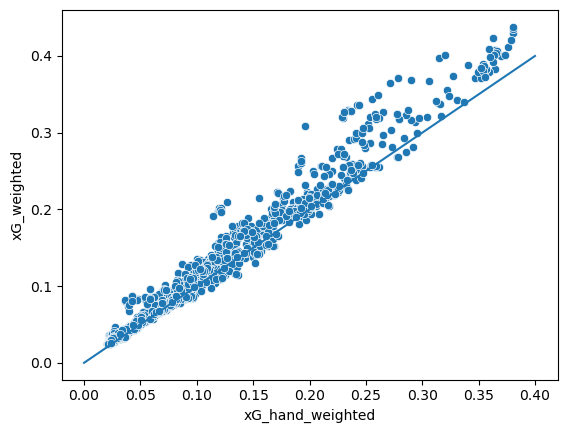

In [778]:
sns.scatterplot(test_season,x='xG_hand_weighted',y='xG_weighted')
plt.plot([0,.4],[0,.4])

We will set this to False if we need to make changes so your notebook runs!

In [779]:
notebook_runs=True

In [780]:
grader.check("Notebook runs")

Notebook runs results: All test cases passed!